### Loading Libraries

In [2]:
import pandas as pd 
import numpy as np 
import warnings
import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')



### Loading Datasets

In [3]:
PATH = r"C:\Users\Kmosala\OneDrive - Pepkor\Desktop\WorkInProgress\Studies\Data\online+retail+ii\online_retail_II.xlsx"

# The file has two sheets - Year 1 and Year 2
print("Loading sheets...")
df_1 = pd.read_excel(PATH, sheet_name='Year 2009-2010', dtype={'Customer ID': str})
df_2 = pd.read_excel(PATH, sheet_name='Year 2010-2011', dtype={'Customer ID': str})

# Stack them into one dataframe
df_raw = pd.concat([df_1, df_2], ignore_index=True)
print(f"shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"Data range: {df_raw['InvoiceDate'].min()} to {df_raw['InvoiceDate'].max()}")
df_raw.head()

Loading sheets...
shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Data range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


## Data Health

In [4]:
print("=== NULL CHECK ===")
print(df_raw.isnull().sum())

print(f"\n=== DATA TYPES ===")
print(df_raw.dtypes)

print(f"\n=== SALES STATS ===")
print(df_raw[['Quantity', 'Price']].describe()) 

print(f"\n=== QUICK COUNTS ===")
print(f"Total Transactions: {df_raw.shape[0]:,}")
print(f"Unique Customers: {df_raw['Customer ID'].nunique():,}")
print(f"Unique Products: {df_raw['StockCode'].nunique():,}")
print(f"Unique Countries: {df_raw['Country'].nunique():,}")
print(f"Canccelled Invoices: {(df_raw['Invoice'].astype(str).str.startswith('C')).sum():,}")
print(f"Negative Quantities: {(df_raw['Quantity'] < 0).sum():,}")
print(f"Zero/negative price: {(df_raw['Price'] <= 0).sum():,}")
print(f"Missing Customer ID: {df_raw['Customer ID'].isnull().sum():,} ({df_raw['Customer ID'].isnull().mean():.1%})")

=== NULL CHECK ===
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

=== DATA TYPES ===
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID            object
Country                object
dtype: object

=== SALES STATS ===
           Quantity         Price
count  1.067371e+06  1.067371e+06
mean   9.938898e+00  4.649388e+00
std    1.727058e+02  1.235531e+02
min   -8.099500e+04 -5.359436e+04
25%    1.000000e+00  1.250000e+00
50%    3.000000e+00  2.100000e+00
75%    1.000000e+01  4.150000e+00
max    8.099500e+04  3.897000e+04

=== QUICK COUNTS ===
Total Transactions: 1,067,371
Unique Customers: 5,942
Unique Products: 5,305
Unique Countries: 43
Canccelled Invoices: 19,494
Negative Quantities: 22,950
Zero/negative p

### Data Cleaning

In [5]:
print("=== BEFORE CLEANING ===")
print(f"Rows: {df_raw.shape[0]:,}")

df = df_raw.copy()

## Drop missing Customer IDs
df = df[df['Customer ID'].notna()]
print(f"\nAfter dropping missing Customer IDs : {df.shape[0]:,} rows removed: {df_raw.shape[0] - df.shape[0]:,}")

## Drop Cancelled Invoices
cancelled_mask = df['Invoice'].astype(str).str.startswith('C')
df = df[~cancelled_mask]
print(f"\nAfter dropping cancelled invoices: {df.shape[0]:,} rows removed: {df_raw.shape[0] - df.shape[0]:,}")

## Drop negative or zero quantities
df = df[df['Quantity'] > 0]
print(f"\nAfter dropping negative/zero quantities: {df.shape[0]:,}")

## Drop negative or zero prices
df = df[df['Price'] > 0]
print(f"\nAfter dropping negative/zero prices: {df.shape[0]:,}")

## Add revenue column
df['Revenue'] = df['Quantity'] * df['Price']

## Clean up Customer ID as string
df['Customer ID'] = df['Customer ID'].astype(str).str.strip()

## reset index
df = df.reset_index(drop=True)

print(f"\n=== AFTER CLEANING ===")
print(f"Final Rows: {df.shape[0]:,}")
print(f"Rows removed: {df_raw.shape[0] - df.shape[0]:,} ({(df_raw.shape[0] - df.shape[0]) / df_raw.shape[0]:.1%})")
print(f"Unique Customers: {df['Customer ID'].nunique():,}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"\nRevenue stats:")
print(df['Revenue'].describe())

=== BEFORE CLEANING ===
Rows: 1,067,371

After dropping missing Customer IDs : 824,364 rows removed: 243,007

After dropping cancelled invoices: 805,620 rows removed: 261,751

After dropping negative/zero quantities: 805,620

After dropping negative/zero prices: 805,549

=== AFTER CLEANING ===
Final Rows: 805,549
Rows removed: 261,822 (24.5%)
Unique Customers: 5,878
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00

Revenue stats:
count    805549.000000
mean         22.026505
std         224.041928
min           0.001000
25%           4.950000
50%          11.850000
75%          19.500000
max      168469.600000
Name: Revenue, dtype: float64


### RFM

In [6]:
## Snapshot data - the "today" from the model's perspective, use 1 day after last transaction
SNAPSHOT = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"\nSnapshot date: {SNAPSHOT.date()}")

## Invoice-level aggregation, One row per invoice - needed for frequency calculation 
invoices = (df.groupby(['Customer ID', 'Invoice', 'InvoiceDate'])
              .agg(invoice_revenue=('Revenue', 'sum'),
                   invoice_items=('Quantity', 'sum'),
                   unique_products=('StockCode', 'nunique'))
              .reset_index())
 
print(f"\nInvoice-level shape: {invoices.shape}")
print(invoices.head(3))


## Customer-level RFM
rfm = (invoices.groupby('Customer ID')
        .agg(
            last_purchase = ('InvoiceDate', 'max'),
            frequency = ('Invoice', 'nunique'),
            monetary = ('invoice_revenue', 'sum'),
            avg_order_value = ('invoice_revenue', 'mean'),
            avg_basket_size = ('invoice_items', 'mean'),
            avg_unique_skus = ('unique_products', 'mean'),
        )
        .reset_index())

## Recency = Days since last purchase
rfm['recency'] = (SNAPSHOT - rfm['last_purchase']).dt.days

## RFM Scores
# Recency: Lower days = better = score 5
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1]).astype(int)

# Frequency: Higher = better = score 5
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 
                          q=5, labels=[1,2,3,4,5]).astype(int)

# Monetary: Higher = better = score 5
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 
                          q=5, labels=[1,2,3,4,5]).astype(int)

# Combine RFM score as string
rfm['RFM_Score'] = (rfm['R_score'].astype(str) + 
                    rfm['F_score'].astype(str) + 
                    rfm['M_score'].astype(str))

## Total RFM
rfm['RFM_Total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print(f"\n=== RFM TABLE (first 5 rows) ===")
print(rfm[['Customer ID', 'recency', 'frequency', 'monetary', 
           'R_score', 'F_score', 'M_score', 'RFM_Score']].head())

print(f"\n=== RFM STATS ===") 
print(rfm[['recency', 'frequency', 'monetary', 'avg_order_value']].describe().round(2))   


Snapshot date: 2011-12-10

Invoice-level shape: (37033, 6)
  Customer ID  Invoice         InvoiceDate  invoice_revenue  invoice_items  \
0       12346   491725 2009-12-14 08:34:00             45.0             10   
1       12346   491742 2009-12-14 11:00:00             22.5              5   
2       12346   491744 2009-12-14 11:02:00             22.5              5   

   unique_products  
0                1  
1                1  
2                1  

=== RFM TABLE (first 5 rows) ===
  Customer ID  recency  frequency  monetary  R_score  F_score  M_score  \
0       12346      326         12  77556.46        2        5        5   
1       12347        2          8   5633.32        5        4        5   
2       12348       75          5   2019.40        3        4        4   
3       12349       19          4   4428.69        5        3        5   
4       12350      310          1    334.40        2        1        2   

  RFM_Score  
0       255  
1       545  
2       344  
3       

### Behavioural Features

In [7]:
## === BEHAVIORAL FEATURES ===

# 1. PURCHASE TIMIMG FEATURES
# When does this customer shop?
df['hour'] = df['InvoiceDate'].dt.hour
df['day_of_week'] = df['InvoiceDate'].dt.day_of_week
df['month'] = df['InvoiceDate'].dt.month

timing = df.groupby('Customer ID').agg(
    favourite_hour = ('hour', lambda x: x.mode()[0]),
    favourite_dow = ('day_of_week', lambda x: x.mode()[0]),
    pct_weekend_orders = ('day_of_week', lambda x: (x >= 5).mean()),
    pct_morning_orders = ('hour', lambda x: (x < 12).mean()),
).reset_index()

# 2. PRODUCT DIVERSITY FEATURES
# How broadly does this customer shop?
diversity  = df.groupby('Customer ID').agg(
    unique_products = ('StockCode', 'nunique'),
    unique_countries = ('Country', 'nunique'),
    total_items_bought = ('Quantity', 'sum'),
).reset_index()

# 3. SPEND CONSISTENCY FEATURES
# Is this customer predictable or erratic?
spend_consistency = (invoices.groupby('Customer ID')['invoice_revenue']
                             .agg(spend_std = 'std', spend_mean = 'mean')
                             .reset_index())

spend_consistency['spend_cv'] = (spend_consistency['spend_std'] / 
                                  spend_consistency['spend_mean'])
spend_consistency = spend_consistency.drop(columns=['spend_std', 'spend_mean'])

# 4. INTERPURCHASE TIME FEATURES
# How regular does this customer's return?
purchase_dates = (invoices.sort_values('InvoiceDate')
                          .groupby('Customer ID')['InvoiceDate']
                          .apply(lambda x: x.diff().dt.days.dropna()))

ipt = (purchase_dates.reset_index()
                     .groupby('Customer ID')['InvoiceDate']
                     .agg(avg_days_between_purchases = 'mean', 
                          std_days_between_purchases = 'std')
                     .reset_index())

# 5. CUSTOMER TENURE
tenure = df.groupby('Customer ID').agg(
    first_purchase = ('InvoiceDate', 'min'),
    last_purchase = ('InvoiceDate', 'max')
).reset_index()
tenure['tenure_days'] = (tenure['last_purchase'] - 
                          tenure['first_purchase']).dt.days
tenure = tenure[['Customer ID', 'tenure_days']]


# 6. SEASONAL SHOPPING PATTERN
# Which quarter does this customer spend most in?
df['quarter'] = df['InvoiceDate'].dt.quarter
quarterly = df.groupby(['Customer ID', 'quarter'])['Revenue'].sum().unstack(fill_value=0)
quarterly.columns = [f'revenue_q{c}' for c in quarterly.columns]
quarterly = quarterly.reset_index()

# === MERGE ALL FEATURES ONTO FRM BASE ===
customers = rfm.copy()
for feature_df in [timing, diversity, spend_consistency, ipt, tenure, quarterly]:
    customers = customers.merge(feature_df, on='Customer ID', how='left')

# Fill NaN from std calculations
customers['spend_cv'] = customers['spend_cv'].fillna(0)
customers['std_days_between_purchases'] = customers['std_days_between_purchases'].fillna(0)
customers['avg_days_between_purchases'] = customers['avg_days_between_purchases'].fillna(
    customers['tenure_days'])

print(f"Total features built: {customers.shape[1] - 1}") 
print(f"Customers : {customers.shape[0]:,}")
print(f"\nAll columns:")
for col in customers.columns:
    print(f" {col}")

Total features built: 27
Customers : 5,878

All columns:
 Customer ID
 last_purchase
 frequency
 monetary
 avg_order_value
 avg_basket_size
 avg_unique_skus
 recency
 R_score
 F_score
 M_score
 RFM_Score
 RFM_Total
 favourite_hour
 favourite_dow
 pct_weekend_orders
 pct_morning_orders
 unique_products
 unique_countries
 total_items_bought
 spend_cv
 avg_days_between_purchases
 std_days_between_purchases
 tenure_days
 revenue_q1
 revenue_q2
 revenue_q3
 revenue_q4


### Segmentation: KMeans 

  File "c:\Users\KMosala\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\KMosala\AppData\Local\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\KMosala\AppData\Local\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\KMosala\AppData\Local\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


k=2 inertia=70,116  silhouette=0.8510
k=3 inertia=58,929  silhouette=0.2330
k=4 inertia=51,993  silhouette=0.2361
k=5 inertia=48,064  silhouette=0.2464
k=6 inertia=42,115  silhouette=0.2319
k=7 inertia=37,694  silhouette=0.2243
k=8 inertia=34,379  silhouette=0.2187
k=9 inertia=31,169  silhouette=0.2482


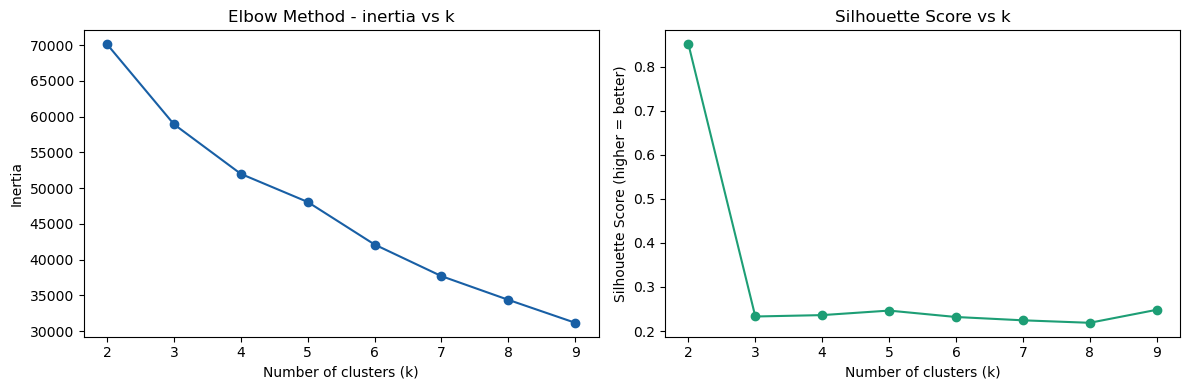


Best k by silhouette: 2


In [8]:
# === Select features for clustering === 
# Using the most meaningful business features

CULSTER_FEATURES = [
    'recency', 'frequency', 'monetary', 
    'avg_order_value', 'avg_basket_size',
    'tenure_days', 'avg_days_between_purchases',
    'spend_cv', 'unique_products', 
    'pct_weekend_orders', 'pct_morning_orders',
    'revenue_q1', 'revenue_q2', 'revenue_q3', 'revenue_q4'
]

X = customers[CULSTER_FEATURES].fillna(0)

# === SCALE FEATURES ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Find optimal number of clusters (Elbow and Silhouette) ===
inertias, silhouettes = [], []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000))
    print(f"k={k} inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'o-', color='#185FA5')
axes[0].set_title('Elbow Method - inertia vs k')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, 'o-', color='#1D9E75')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
#plt.savefig('../charts/cluster_selection.png', dpi=150)    
plt.show()

print(f"\nBest k by silhouette: {K_range[silhouettes.index(max(silhouettes))]}")

### Outliers

In [9]:
# See the outlier problem clearly
print("Revenue distribution:")
print(customers['monetary'].describe().round(0))

print(f"\Customer spending > 50,000: {(customers['monetary'] > 50000).sum()}")
print(f"\Customer spending > 10,000: {(customers['monetary'] > 10000).sum()}")
print(f"\Customer spending < 10,000: {(customers['monetary'] < 10000).sum()}")  

# Separate wholesale from retail
# Wholesale = top 1% by monetary value OR frequency > 100
wholesale_mask = (customers['monetary'] > customers['monetary'].quantile(0.99)) | \
                 (customers['frequency'] > 100)

wholesale  = customers[wholesale_mask].copy()
retail = customers[~wholesale_mask].copy()

print(f"\nWholesale customers (top 1% spenders or freq > 100): {len(wholesale):,}")
print(f"Retail customers: {len(retail):,}")
print(f"\nWholesale avg spend: {wholesale['monetary'].mean():,.0f}")
print(f"Retail avg spend: {retail['monetary'].mean():,.0f}")

Revenue distribution:
count      5878.0
mean       3019.0
std       14738.0
min           3.0
25%         349.0
50%         899.0
75%        2307.0
max      608822.0
Name: monetary, dtype: float64
\Customer spending > 50,000: 35
\Customer spending > 10,000: 267
\Customer spending < 10,000: 5611

Wholesale customers (top 1% spenders or freq > 100): 61
Retail customers: 5,817

Wholesale avg spend: 93,621
Retail avg spend: 2,069


### k=4 Fit

In [10]:
# === FIT FINAL MODEL ON RETAIL SEGMENT ===
X_retail = retail[CULSTER_FEATURES].fillna(0)
X_retail_scaled = scaler.fit_transform(X_retail)

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
retail = retail.copy()
retail['cluster'] = km_final.fit_predict(X_retail_scaled)

# === PROFILE EACH CLUSTER ===
profile_cols = ['recency', 'frequency', 'monetary', 
                'avg_order_value', 'tenure_days', 
                'avg_days_between_purchases', 'unique_products']

profile = (retail.groupby('cluster')[profile_cols]
                    .mean()
                    .round(1))

print("=== CLUSTER PROFILES ===")
print(profile.to_string())

=== CLUSTER PROFILES ===
         recency  frequency  monetary  avg_order_value  tenure_days  avg_days_between_purchases  unique_products
cluster                                                                                                         
0           46.1       23.1   11712.9            742.1        613.5                        35.7            265.7
1           97.4        6.4    2076.1            348.1        432.5                       126.8             96.7
2          438.0        1.0   11880.8          11880.8          0.0                         0.0             45.0
3          341.2        1.7     484.4            306.8         39.0                        24.2             28.1


### Visuals

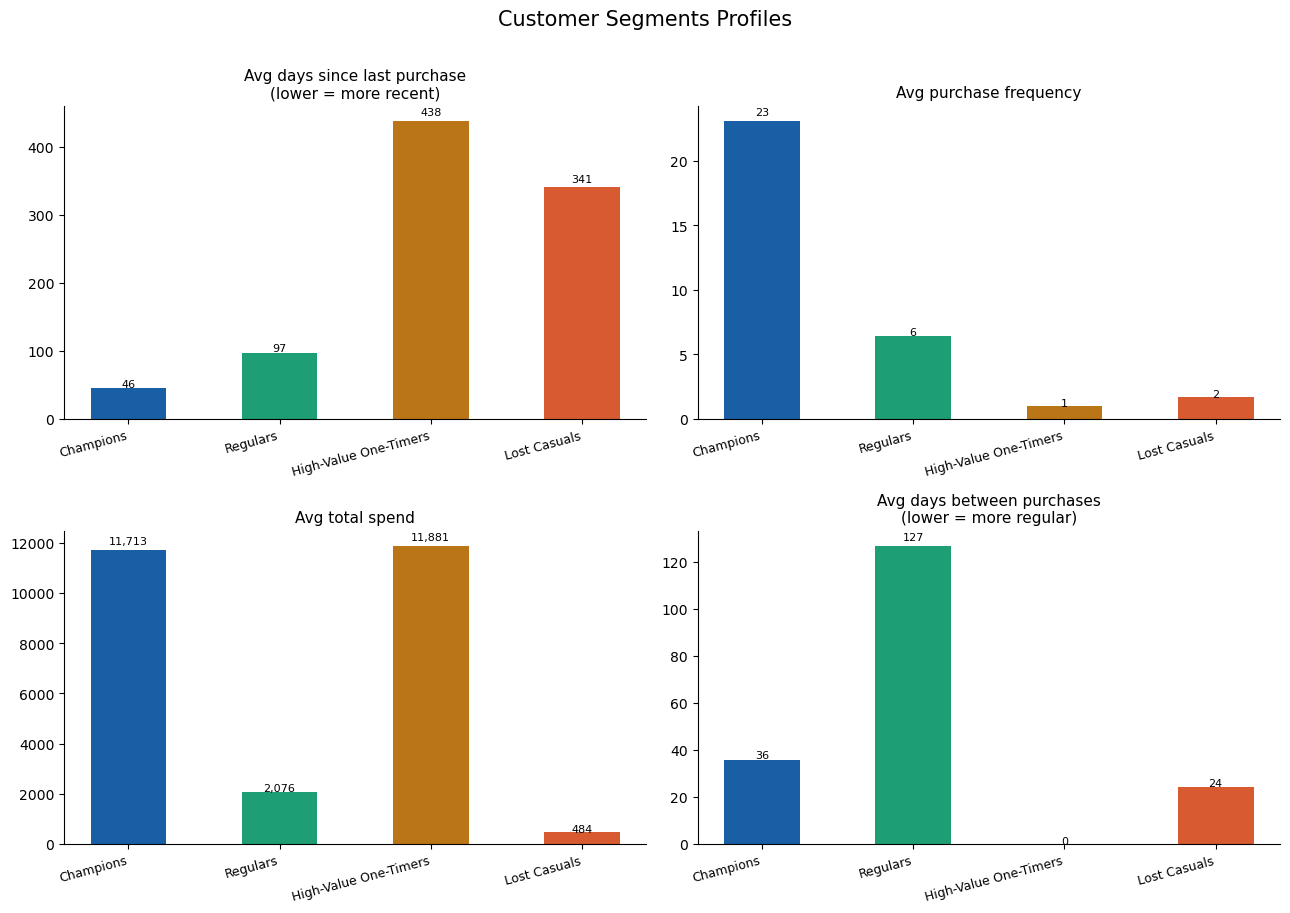

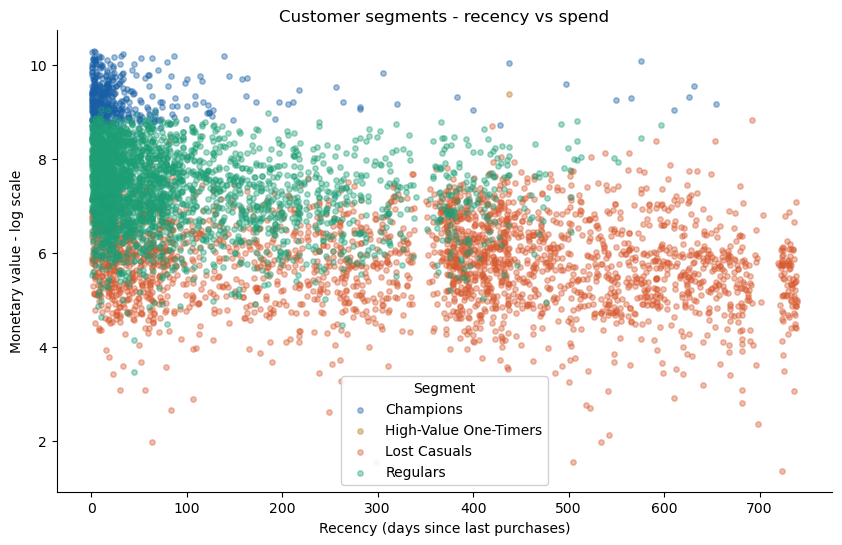

CUSTOMER SEGMENT STRATEGY
                       customers  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_share
segment                                                                                                 
Champions                    425         46.1           23.1       11712.9      4977987.9           41.4
Regulars                    2784         97.4            6.4        2076.1      5779967.8           48.0
High-Value One-Timers          1        438.0            1.0       11880.8        11880.8            0.1
Lost Casuals                2607        341.2            1.7         484.4      1262722.1           10.5


=== BUSINESS ACTIONS BY SEGMENT ===

🔵 CHAMPIONS
   → VIP loyalty programme — early access to new products
   → Ask for reviews and referrals — NPS surveys
   → Increase catalogue cross-sell — they already buy 266 products
   → Do NOT discount heavily — they buy at full price already

🟢 REGULARS
   → Nudge toward Champions with personalised

In [11]:
# === NAME THE SEGMENTS ===
segment_names = {
    0: 'Champions',
    1: 'Regulars',
    2: 'High-Value One-Timers',
    3: 'Lost Casuals'
}
segment_colors = {
    0: '#185FA5',
    1: '#1D9E75',
    2: '#BA7517',
    3: '#D85A30'
}
retail['segment'] = retail['cluster'].map(segment_names)
retail['seg_color'] = retail['cluster'].map(segment_colors) 

# === Segment overview - 4 key metrics ===
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Customer Segments Profiles', fontsize=15, fontweight='normal', y=1.01)


metrics = [('recency', 'Avg days since last purchase\n(lower = more recent)'),
           ('frequency', 'Avg purchase frequency'),
           ('monetary', 'Avg total spend'),
           ('avg_days_between_purchases', 'Avg days between purchases\n(lower = more regular)')

]

seg_order = ['Champions', 'Regulars', 'High-Value One-Timers', 'Lost Casuals']
colors = [segment_colors[i] for i in range(4)]

for ax, (col, title) in zip(axes.flatten(), metrics):
    vals = [profile.loc[retail[retail['segment']==s]['cluster'].iloc[0], col]
            for s in seg_order]
    bars = ax.bar(seg_order, vals, color=colors, width=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xticklabels(seg_order, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{val:,.0f}', ha='center', fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


# === PLOT 2: Recency vs Monetary scatter ===
fig, ax = plt.subplots(figsize=(10,6))
for seg, grp in retail.groupby('segment'):
    color = segment_colors[list(segment_names.values()).index(seg)]
    ax.scatter(grp['recency'],
               np.log1p(grp['monetary']),
               c=color, alpha=0.4, s=15, label=seg)

ax.set_xlabel('Recency (days since last purchases)')
ax.set_ylabel('Monetary value - log scale')
ax.set_title('Customer segments - recency vs spend')
ax.legend(title='Segment', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('segment_scatter.png', dpi=150)
plt.show()

# === SEGMENT SUMMARY TABLE ===
summary = (retail.groupby('segment')
                 .agg(
                    customers = ('Customer ID', 'count'),
                    avg_recency = ('recency', 'mean'),
                    avg_frequency = ('frequency', 'mean'),
                    avg_monetary = ('monetary', 'mean'),
                    total_revenue = ('monetary', 'sum'),
            )
            .round(1))

summary['revenue_share'] = (summary['total_revenue'] /
                             summary['total_revenue'].sum() * 100).round(1)
summary = summary.loc[seg_order]

print("=" * 75)
print("CUSTOMER SEGMENT STRATEGY")
print("=" * 75)
print(summary.to_string())

print("\n\n=== BUSINESS ACTIONS BY SEGMENT ===\n")
actions = {
    'Champions': [
        "VIP loyalty programme — early access to new products",
        "Ask for reviews and referrals — NPS surveys",
        "Increase catalogue cross-sell — they already buy 266 products",
        "Do NOT discount heavily — they buy at full price already"
    ],
    'Regulars': [
        "Nudge toward Champions with personalised reactivation (email/push)",
        "Bundle offers to increase avg order value from 348 → 500+",
        "Loyalty points accelerator — double points next 30 days",
        "Target with new arrivals in their top categories"
    ],
    'High-Value One-Timers': [
        "HIGHEST PRIORITY win-back — one visit worth 11,881",
        "Personalised outreach referencing their original purchase",
        "Offer trade account or B2B pricing if they are a business",
        "Win-back email sequence: 3 touches over 30 days"
    ],
    'Lost Casuals': [
        "Low investment — sunset after 1 re-engagement attempt",
        "Mass discount offer (20% off) as final win-back",
        "Suppress from expensive channels (direct mail, paid)",
        "Analyse exit surveys to understand why they left"
    ]
}

for seg, acts in actions.items():
    color_code = {'Champions':'🔵','Regulars':'🟢',
                  'High-Value One-Timers':'🟡','Lost Casuals':'🔴'}
    print(f"{color_code[seg]} {seg.upper()}")
    for a in acts:
        print(f"   → {a}")
    print()

In [13]:
# === SAVE EVERYTHING NEEDED FOR GITHUB ===

# 1. Save the full customer feature table
customers_export = retail.copy()
customers_export.to_csv('customer_features.csv', index=False)
print(f"Saved customer_features.csv — {customers_export.shape}")

# 2. Save segment summary
summary.to_csv('segment_summary.csv')
print(f"Saved segment_summary.csv")

# 3. Final project stats for README
total_rev = retail['monetary'].sum()
champ_rev_share = retail[retail['segment']=='Champions']['monetary'].sum() / total_rev
print(f"""
=== STATS ===
Dataset        : Online Retail II (UCI)
Period         : Dec 2009 – Dec 2011
Raw rows       : 1,067,371
Clean rows     : 805,549
Customers      : {retail.shape[0]:,}
Features built : 27

SEGMENTS
  Champions             : {(retail['segment']=='Champions').sum():,} customers ({(retail['segment']=='Champions').mean():.1%}) → {champ_rev_share:.1%} of revenue
  Regulars              : {(retail['segment']=='Regulars').sum():,} customers
  High-Value One-Timers : {(retail['segment']=='High-Value One-Timers').sum():,} customers
  Lost Casuals          : {(retail['segment']=='Lost Casuals').sum():,} customers

KEY INSIGHT
  Top 7% of customers (Champions) drive 41% of revenue
  Winning back 10% of Lost Casuals = ~£330k incremental revenue
""")

Saved customer_features.csv — (5817, 31)
Saved segment_summary.csv

=== STATS ===
Dataset        : Online Retail II (UCI)
Period         : Dec 2009 – Dec 2011
Raw rows       : 1,067,371
Clean rows     : 805,549
Customers      : 5,817
Features built : 27

SEGMENTS
  Champions             : 425 customers (7.3%) → 41.4% of revenue
  Regulars              : 2,784 customers
  High-Value One-Timers : 1 customers
  Lost Casuals          : 2,607 customers

KEY INSIGHT
  Top 7% of customers (Champions) drive 41% of revenue
  Winning back 10% of Lost Casuals = ~£330k incremental revenue

